In [33]:
%pip install numpy pandas matplotlib python-pptx

In [1]:
import sys  # noqa
# sys.path.append('/workspace/forecasting_simulation')  # noqa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns 
import matplotlib.colors as mcolors
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from utilss import * 

## Load the Data

In [46]:
import pandas as pd

# Load the data
data = pd.read_excel('BESTPAK - Processed LP June - September 2024.xlsx')
data['datetime'] = pd.to_datetime(data['datetime'])  # Ensure datetime is in correct format

# Check the number of columns in the DataFrame
num_columns = data.shape[1]

# Column indices: 8th column (index 7) for kwh and 9th column (index 8) for kw
kwh_column_idx = 7  # 8th column (0-based index)
kw_column_idx = 8   # 9th column (0-based index)

# Check datetime interval to determine if it's 5-minute or 1-hour data
time_diff = data['datetime'].diff().dt.total_seconds().median()
frequency = 12 if time_diff == 300 else 1  # 5-minute interval if median diff is 300 seconds, otherwise 1 hour

# Handling 5-minute data
if frequency == 12:  # 5-minute interval
    print("Data is 5-minute interval.")

    # Check if there are 8 or 9 columns
    if num_columns == 8:
        # Check if the 8th column is named as 'kw'
        if data.columns[kwh_column_idx].lower() == 'kw':
            # Rename it to 'kwh' and create 'kw' as the 9th column
            data.rename(columns={data.columns[kwh_column_idx]: 'kwh'}, inplace=True)
            data['kw'] = data['kwh'] * 12  # Create the 9th column by multiplying kwh by 12
        else:
            # If it's already kwh, just create 'kw' column
            data['kw'] = data.iloc[:, kwh_column_idx] * 12  # Create the 9th column by multiplying kwh by 12
            data.rename(columns={data.columns[kwh_column_idx]: 'kwh'}, inplace=True)
            
        # Ensure the data has 9 columns now
        print(f"Data now has {data.shape[1]} columns (9 columns expected).")

    elif num_columns == 9:
        # Simply rename the 8th and 9th columns as kwh and kw
        data.rename(columns={data.columns[kwh_column_idx]: 'kwh', data.columns[kw_column_idx]: 'kw'}, inplace=True)

# Handling 1-hour data
elif frequency == 1:  # 1-hour interval
    print("Data is 1-hour interval.")

    # Check if there are 8 or 9 columns
    if num_columns == 8:
        # Copy the value from the 8th column (kwh) to the 9th column (kw)
        data['kw'] = data.iloc[:, kwh_column_idx]
        # Rename the columns appropriately
        data.rename(columns={data.columns[kwh_column_idx]: 'kwh', 'kw': 'kw'}, inplace=True)
        print(f"Data now has {data.shape[1]} columns (9 columns expected).")

    elif num_columns == 9:
        # Ensure the 8th and 9th columns are the same
        if not (data.iloc[:, kwh_column_idx] == data.iloc[:, kw_column_idx]).all():
            print("Warning: 8th and 9th columns do not match.")
        # Rename the columns as kwh and kw
        data.rename(columns={data.columns[kwh_column_idx]: 'kwh', data.columns[kw_column_idx]: 'kw'}, inplace=True)

# Show first few rows to verify the results
print(data.head())


Data is 5-minute interval.
  supply period            datetime       date  correct hour  hour  weekday  \
0        Jun-24 2024-05-26 00:00:00 2024-05-26             0     1        6   
1        Jun-24 2024-05-26 00:05:00 2024-05-26             0     1        6   
2        Jun-24 2024-05-26 00:10:00 2024-05-26             0     1        6   
3        Jun-24 2024-05-26 00:15:00 2024-05-26             0     1        6   
4        Jun-24 2024-05-26 00:20:00 2024-05-26             0     1        6   

        wesm       kwh          kw  
0   4.439488  9.172917  110.075000  
1  29.602327  9.172917  110.075000  
2   5.438852  9.172917  110.075000  
3   5.136947  9.197222  110.366667  
4   5.121760  9.197222  110.366667  


In [47]:
# Check the columns in your data
print(data.columns)

Index(['supply period', 'datetime', 'date', 'correct hour', 'hour', 'weekday',
       'wesm', 'kwh', 'kw'],
      dtype='object')


In [48]:
# Generate energy summary
energy_summary = generate_energy_summary(data, kwh_column='kwh', kw_column='kw')
energy_summary

,supply period,number of hours,kwh,kw,load factor
0,Jun-24,744.00,"73,754.48",142.74,69.45
1,Jul-24,720.00,"69,655.22",136.85,70.69
2,Aug-24,744.00,"70,411.26",135.57,69.81
3,Sep-24,744.00,"80,147.94",151.20,71.25
4,Total,"2,952.00","293,968.91",151.20,65.86
5,Average,738.00,"73,492.23",141.59,70.30
6,Max,744.00,"80,147.94",151.20,71.25
7,Min,720.00,"69,655.22",135.57,69.45


## Plot Energy behavior

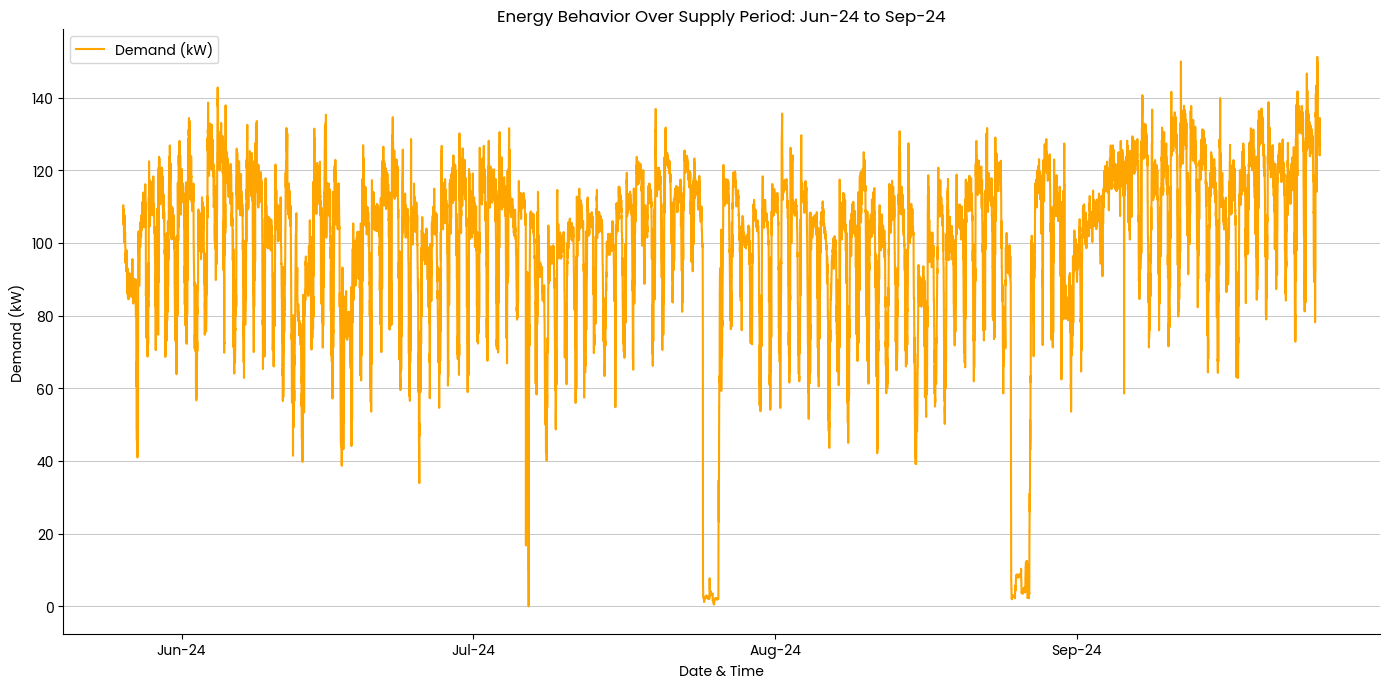

In [49]:
# Call the function to plot
energy_behavior_plot(data)

c:\Users\MARK\Insights_Automation\utilss.py:198: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_data['kwh'] = monthly_data['kwh'].str.replace(',', '').astype(float)
c:\Users\MARK\Insights_Automation\utilss.py:199: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_data['kw'] = monthly_data['kw'].str.replace(',', '').astype(float)


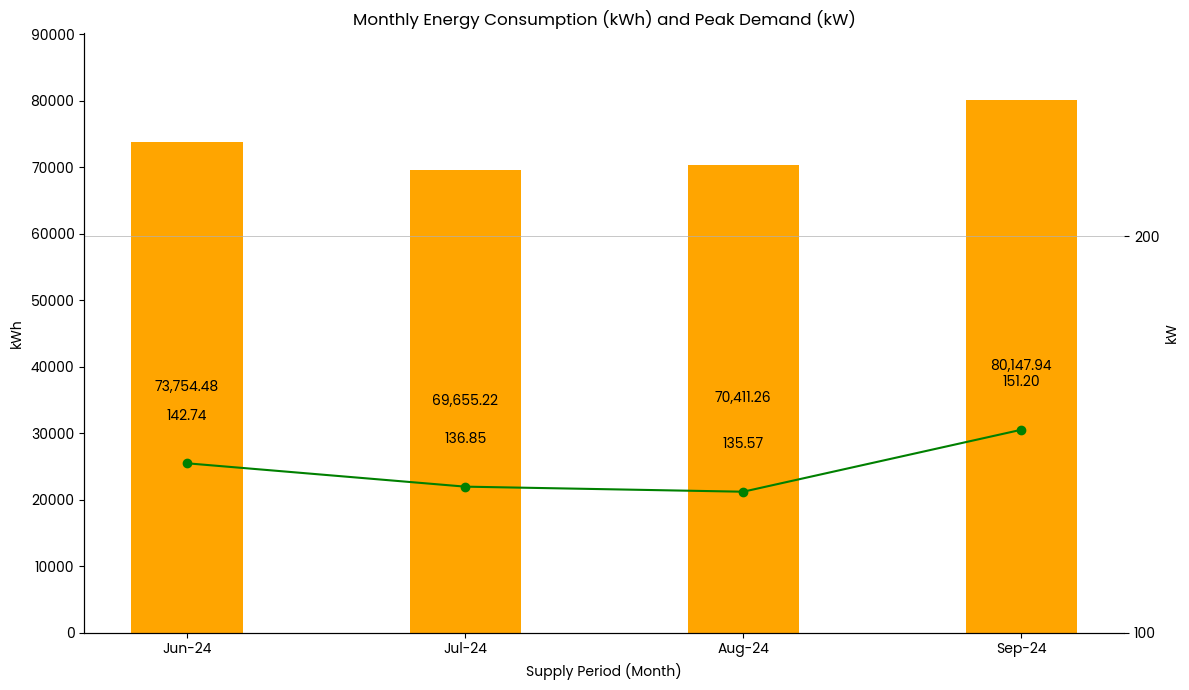

In [50]:
save_energy_consumption_plot(energy_summary)

In [51]:
# Filter out rows labeled 'Total', 'Average', 'Max', or 'Min'
filtered_energy_summary = energy_summary[~energy_summary['supply period'].isin(['Total', 'Average', 'Max', 'Min'])]

# Select the relevant columns for months and load factor
months_load_factor = filtered_energy_summary[['supply period', 'load factor']].copy()

# Set 'supply period' as the index directly (without converting to datetime)
months_load_factor.set_index('supply period', inplace=True)

# Convert 'load factor' to numeric (float) if it's in string format
months_load_factor['load factor'] = pd.to_numeric(months_load_factor['load factor'], errors='coerce')

# Remove any remaining rows with NaN values in 'load factor'
months_load_factor.dropna(subset=['load factor'], inplace=True)

# Convert the load factor to a percentage format, assuming values are already correctly scaled
months_load_factor['load factor'] = months_load_factor['load factor'].round(2).astype(str) + '%'

# Transpose the DataFrame so each supply period is a column
transposed_table = months_load_factor.T

# Display the transposed table
transposed_table


supply period,Jun-24,Jul-24,Aug-24,Sep-24
load factor,69.45%,70.69%,69.81%,71.25%


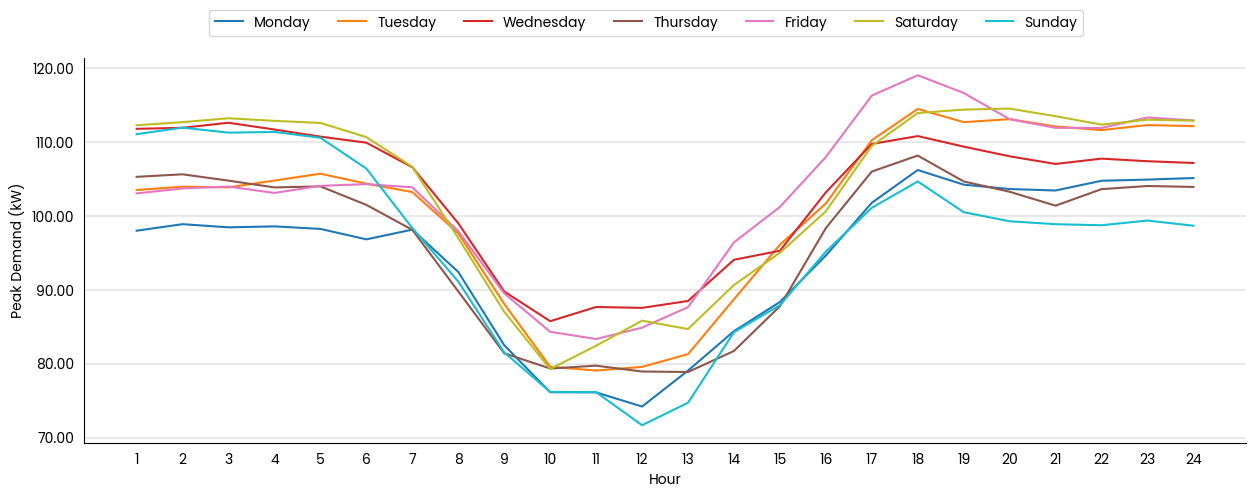

In [52]:
# Average by Hour
hourly_load_curve_by_day = data.pivot_table(
  index="hour",
  columns="weekday",
  values="kw",
  aggfunc={
    "kw": "mean"
  }
)
 
# Convert from kW to MW
# hourly_load_curve_by_day = hourly_load_curve_by_day / 1000
 
# Get list of days of the week
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
 
plot_hourly_by_day_load_curve(hourly_load_curve_by_day, column_name='max', unit='kW')

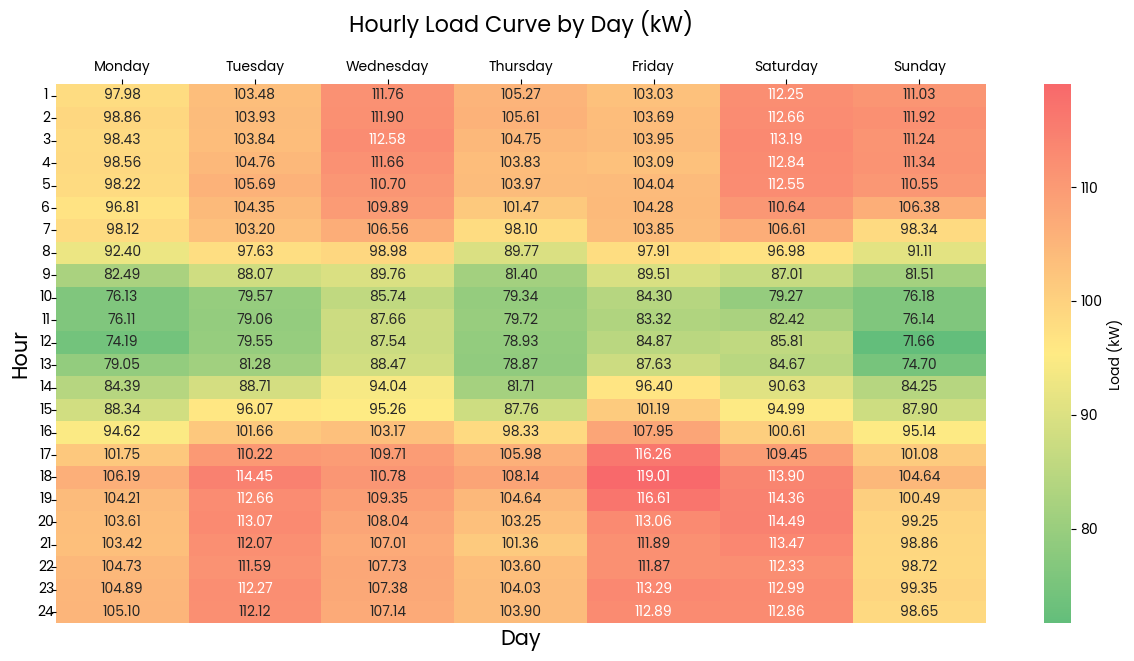

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.colors as mcolors

# Define the new color map based on the provided colors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "", ["#63BE7B", "#FFEB84", "#F8696B"]  # Custom colors for the heatmap
)

# Define weekday labels
weekday_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Display the hourly load curve by day as a heatmap table with the new color map
def display_hourly_by_day_table(hourly_by_day_summary):
    plt.figure(figsize=(15, 7))
    ax = sns.heatmap(
        hourly_by_day_summary,
        annot=True,
        fmt=".2f",
        cmap=cmap,  # Use the updated colormap
        cbar_kws={'label': 'Load (kW)'}
    )
    
    # Move x-axis labels to the top
    ax.xaxis.set_ticks_position('top')
    
    # Set custom labels for the x-axis on top with centered alignment
    ax.set_xticks(np.arange(len(weekday_labels)) + 0.5)
    ax.set_xticklabels(weekday_labels, rotation=0, ha='center')

    # Rotate y-axis (hour) labels to make them vertical
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='center')
    
    plt.xlabel("Day", fontsize=15)  # X-axis title at the top
    plt.ylabel("Hour", fontsize=15)  # Y-axis title

    plt.title("Hourly Load Curve by Day (kW)", fontsize=16, pad=20)  # Add padding to title
    plt.show()

# Use the function to display the table as a heatmap
display_hourly_by_day_table(hourly_load_curve_by_day)


In [54]:
import os
print(os.path.exists("solx.ppt"))

False


In [55]:
from pptx.util import Inches

ppt = Presentation('solx.pptx')
title_slide_layout = ppt.slide_layouts[0]  # Title slide
content_slide_layout = ppt.slide_layouts[1]  # Content slide
section_slide_layout = ppt.slide_layouts[3]  # Section slide
two_content_slide_layout = ppt.slide_layouts[4]  # Two content slide


In [56]:
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx import Presentation

# Function to add a table with content to a PowerPoint slide
def add_table_to_slide(slide, data, x, y, width, height):
    # Get the number of rows and columns from the DataFrame
    rows = len(data) + 1  # Including header row
    cols = len(data.columns)
    
    # Add table to slide
    table = slide.shapes.add_table(rows, cols, x, y, width, height).table
    
    # Adjust column widths to fit the content
    for i in range(cols):
        column_width = max([len(str(data.iloc[j, i])) for j in range(len(data))])  # Find max string length in each column
        table.columns[i].width = Inches(column_width * 0.2)  # Adjust factor (0.2) based on average character width

    # Set row height (fix row height for uniformity)
    row_height = Inches(0.5)  # Set a reasonable row height to ensure rows are not squished
    for row in table.rows:
        row.height = row_height

    # Add header with orange background and white font
    for col_idx, col_name in enumerate(data.columns):
        cell = table.cell(0, col_idx)
        cell.text = str(col_name)
        cell.fill.solid()
        cell.fill.fore_color.rgb = RGBColor(255, 102, 0)  # Orange
        cell.text_frame.paragraphs[0].font.color.rgb = RGBColor(255, 255, 255)  # White
        cell.text_frame.paragraphs[0].font.size = Pt(12)  # Header font size

    # Fill table with data and adjust font size for each cell
    for row_idx, row_data in enumerate(data.values):
        for col_idx, cell_value in enumerate(row_data):
            cell = table.cell(row_idx + 1, col_idx)  # +1 to skip the header row
            cell.text = str(cell_value)
            cell.text_frame.paragraphs[0].font.size = Pt(10)  # Adjust the font size for content

    return table

# Add the energy summary table to the slide
add_table_to_slide(slide, energy_summary, x=Inches(1), y=Inches(1.5), width=Inches(8), height=Inches(3))

NameError: name 'slide' is not defined

In [24]:
ppt.save("solx_energy_report1.pptx")